In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory:

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All".
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session.

/kaggle/input/new-york-city-taxi-fare-prediction/sample_submission.csv
/kaggle/input/new-york-city-taxi-fare-prediction/GCP-Coupons-Instructions.rtf
/kaggle/input/new-york-city-taxi-fare-prediction/train.csv
/kaggle/input/new-york-city-taxi-fare-prediction/test.csv


## Imports:

In [2]:
import pandas as pd
import numpy as np
import xgboost as xg
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor
from datetime import date
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from pyproj import Geod
from pandas.tseries.holiday import USFederalHolidayCalendar
from scipy.stats import boxcox

## Data and Exploring Data:

In [3]:
#loading data
train_fare = pd.read_csv('/kaggle/input/new-york-city-taxi-fare-prediction/train.csv',nrows = 400000)
test_fare = pd.read_csv('/kaggle/input/new-york-city-taxi-fare-prediction/test.csv')
train_fare.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [4]:
Airports = [
    [40.641766, -73.780968], # John F. Kennedy International Airport (JFK)
    [40.776863, -73.874069], # LaGuardia Airport (LGA)
    [40.689491, -74.174538], # Newark Liberty International Airport (EWR)
    [40.85889, -74.05667], # Teterboro Airport (TEB)
    [40.72889, -73.41333], # Republic Airport (FRG)
    [41.066833066, -73.704497182], # Westchester County Airport (HPN)
    [40.754626, -74.006808], # Heliport (likely refers to one in Manhattan)
    [40.733991, -73.972915], # Skyports Heliport
    [40.738830378, -73.969829454], # Another Heliport (presumably in Manhattan)
    [41.50249799, -74.102832922], # Stewart International Airport (SWF)
    [40.790496838, -73.100166266], # MacArthur Airport (ISP)
    [42.742830362, -73.801163462] # Albany International Airport (ALB)
]

def distance_geod(lon1,lat1,lon2,lat2):
    az12,az21,dist = Geod(ellps='WGS84').inv(lon1,lat1,lon2,lat2)
    return dist
def direction_geod(lon1,lat1,lon2,lat2):
    az12,az21,dist = Geod(ellps='WGS84').inv(lon1,lat1,lon2,lat2)
    return az12

def is_near_airport(lon1, lat1, lon2, lat2, threshold=1):
    for airport_coords in Airports:
        distance_to_pickup = haversine(lon1, lat1, airport_coords[1], airport_coords[0])
        distance_to_dropoff = haversine(lon2, lat2, airport_coords[1], airport_coords[0])
        if distance_to_pickup < threshold or distance_to_dropoff < threshold:
            return 1
    return 0

def get_season(pickup):
    month = pickup.month
    if month in [12, 1, 2]:
        return 1
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    elif month in [9, 10, 11]:
        return 4

def get_gas_price(pickup):
    year = pickup.year
    if year in [2000, 2001, 2002, 2003, 2004]:
        return 1.786
    elif year in [2005, 2006]:
        return 2.246  
    elif year in [2008]:
        return 3.935
    elif year in [2009]:
        return 3.935
    elif year in [2010]:
        return 2.780
    elif year in [2011]:
        return 3.482
    elif year in [2012]:
        return 3.702
    elif year in [2013]:
        return 3.567
    elif year in [2014]:
        return 3.670
    elif year in [2015]:
        return 2.877
    elif year in [2016]:
        return 2.482
    elif year in [2017]:
        return 2.525
    elif year in [2018]:
        return 2.924
    elif year in [2019]:
        return 2.798
    elif year in [2020]:
        return 2.265
    elif year in [2021]:
        return 3.216
    elif year in [2022]:
        return 4.977
    
# def box_cox(distn):
#     return boxcox(distn)[0]


# vectorized haversine function
def haversine(lat1, lon1, lat2, lon2, to_radians=True, earth_radius=6371):
    if to_radians:
        lat1, lon1, lat2, lon2 = np.radians([lat1, lon1, lat2, lon2])
    a = np.sin((lat2-lat1)/2.0)**2 + \
        np.cos(lat1) * np.cos(lat2) * np.sin((lon2-lon1)/2.0)**2
    return earth_radius * 2 * np.arcsin(np.sqrt(a))

def distance(pickup_latitude, pickup_longitude, dropoff_latitude, dropoff_longitude):
    return np.abs(dropoff_latitude - pickup_latitude) + np.abs(dropoff_longitude - pickup_longitude)

def add_features(df):
    nyc = (40.724944, -74.001541)

    df['abs_long_diff'] = np.abs(df.dropoff_longitude - df.pickup_longitude)
    df['abs_lat_diff'] = np.abs(df.dropoff_latitude - df.pickup_latitude)
    df['dist'] = haversine(df.pickup_latitude, df.pickup_longitude, df.dropoff_latitude, df.dropoff_longitude)
    df['manh_dist'] = haversine(df.pickup_latitude, df.pickup_longitude, df.dropoff_latitude,
                                df.pickup_longitude) + haversine(df.pickup_latitude, df.pickup_longitude, df.pickup_latitude, df.dropoff_longitude)
    df['distance_geod'] = df.apply(lambda row: distance_geod(row.pickup_longitude, row.pickup_latitude, row.dropoff_longitude, row.dropoff_latitude), axis=1)
    df['direction_geod'] = df.apply(lambda row: direction_geod(row.pickup_longitude, row.pickup_latitude, row.dropoff_longitude, row.dropoff_latitude), axis=1)
    df['pickup_distance_to_center'] = distance(nyc[0], nyc[1], df.pickup_latitude, df.pickup_longitude)
    df['dropoff_distance_to_center'] = distance(nyc[0], nyc[1], df.dropoff_latitude, df.dropoff_longitude)

    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
    df['second'] = df['pickup_datetime'].dt.second
    df['minute'] = df['pickup_datetime'].dt.minute
    df['hour'] = df['pickup_datetime'].dt.hour
    df['day'] = df['pickup_datetime'].dt.day
    df['month'] = df['pickup_datetime'].dt.month
    df['gas_price'] = df['pickup_datetime'].apply(get_gas_price)
    df['week'] = df['pickup_datetime'].dt.isocalendar().week
    df['year'] = df['pickup_datetime'].dt.year
    df['is_night'] = ((df['hour'] >= 21) | (df['hour'] < 6)).astype(int)
    df['weekday'] = df['pickup_datetime'].dt.weekday
    df['is_weekend'] = ((df["weekday"] >=5) &
                    (df["weekday"] <=6)).astype(int)
    df['season'] = df['pickup_datetime'].apply(get_season)
    df['dayofyear']=df['pickup_datetime'].dt.dayofyear
    df['is_leap_year']=df['pickup_datetime'].dt.is_leap_year.astype(int)
    days_in_year = df['is_leap_year'].apply(lambda x: 366 if x else 365)
    df['day_fraction'] = df['dayofyear'] / days_in_year
    
    df['near_airport'] = df.apply(lambda row: is_near_airport(row['pickup_longitude'], row['pickup_latitude'], row['dropoff_longitude'], row['dropoff_latitude']), axis=1)
    df['is_rush_hour'] = df['hour'].apply(lambda x: 1 if x >= 7 and x <= 10 or x >= 16 and x <= 19 else 0)
    df['high_fare_years'] = (df['year'] <= 2012).astype(int)
    df['low_fare_years'] = (df['year'] > 2012).astype(int)

    df_new = pd.to_datetime(df[['year','month','day']])
    df_new.index = pd.to_datetime(df_new)

    cal = USFederalHolidayCalendar()
    hol = cal.holidays(start='2000-01-01', end='2030-01-01')
    df['holiday'] = np.where(df_new.index.to_period('D').astype('datetime64[ns]').isin(hol),1, 0)
    
# feature generation:
add_features(train_fare)
add_features(test_fare)
train_fare.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,abs_long_diff,abs_lat_diff,...,is_weekend,season,dayofyear,is_leap_year,day_fraction,near_airport,is_rush_hour,high_fare_years,low_fare_years,holiday
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21+00:00,-73.844311,40.721319,-73.841610,40.712278,1,0.002701,0.009041,...,0,3,166,0,0.454795,0,1,1,0,0
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16+00:00,-74.016048,40.711303,-73.979268,40.782004,1,0.036780,0.070701,...,0,1,5,0,0.013699,0,1,1,0,0
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00+00:00,-73.982738,40.761270,-73.991242,40.750562,2,0.008504,0.010708,...,0,3,230,0,0.630137,0,0,1,0,0
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42+00:00,-73.987130,40.733143,-73.991567,40.758092,1,0.004437,0.024949,...,1,2,112,1,0.306011,0,0,1,0,0
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00+00:00,-73.968095,40.768008,-73.956655,40.783762,1,0.011440,0.015754,...,0,2,68,0,0.186301,1,1,1,0,0


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


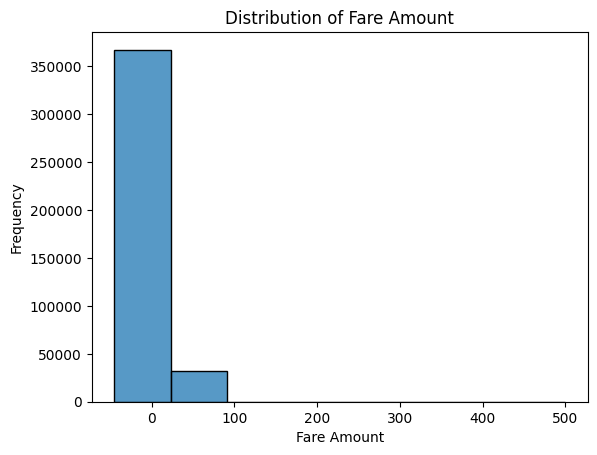

In [5]:
sns.histplot(train_fare['fare_amount'], bins=8)
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Fare Amount')
plt.show()

<Axes: xlabel='fare_amount'>

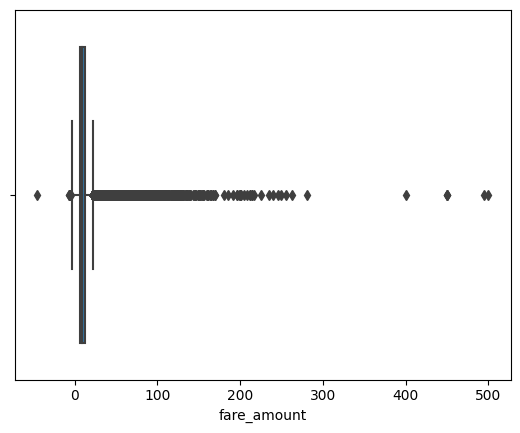

In [6]:
sns.boxplot(x = train_fare['fare_amount'])

In [7]:
train_fare.isna().sum()

key                            0
fare_amount                    0
pickup_datetime                0
pickup_longitude               0
pickup_latitude                0
dropoff_longitude              3
dropoff_latitude               3
passenger_count                0
abs_long_diff                  3
abs_lat_diff                   3
dist                           3
manh_dist                      3
distance_geod                 10
direction_geod                10
pickup_distance_to_center      0
dropoff_distance_to_center     3
second                         0
minute                         0
hour                           0
day                            0
month                          0
gas_price                      0
week                           0
year                           0
is_night                       0
weekday                        0
is_weekend                     0
season                         0
dayofyear                      0
is_leap_year                   0
day_fracti

In [8]:
train_fare = train_fare.dropna()
train_fare.info()

<class 'pandas.core.frame.DataFrame'>
Index: 399990 entries, 0 to 399999
Data columns (total 36 columns):
 #   Column                      Non-Null Count   Dtype              
---  ------                      --------------   -----              
 0   key                         399990 non-null  object             
 1   fare_amount                 399990 non-null  float64            
 2   pickup_datetime             399990 non-null  datetime64[ns, UTC]
 3   pickup_longitude            399990 non-null  float64            
 4   pickup_latitude             399990 non-null  float64            
 5   dropoff_longitude           399990 non-null  float64            
 6   dropoff_latitude            399990 non-null  float64            
 7   passenger_count             399990 non-null  int64              
 8   abs_long_diff               399990 non-null  float64            
 9   abs_lat_diff                399990 non-null  float64            
 10  dist                        399990 non-null  floa

In [9]:
# Drop outliers for fare amount:
train_fare = train_fare.drop(train_fare[(train_fare['fare_amount'] <= 0.01) | (train_fare['fare_amount'] > 300)].index)
train_fare.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,abs_long_diff,abs_lat_diff,dist,manh_dist,...,is_weekend,season,dayofyear,is_leap_year,day_fraction,near_airport,is_rush_hour,high_fare_years,low_fare_years,holiday
count,399951.000000,399951.000000,399951.000000,399951.000000,399951.000000,399951.000000,399951.000000,399951.000000,399951.000000,399951.000000,...,399951.000000,399951.000000,399951.000000,399951.000000,399951.000000,399951.000000,399951.000000,399951.000000,399951.000000,399951.000000
mean,11.357236,-72.518481,39.922120,-72.509761,39.919849,1.683461,0.173373,0.091816,19.291938,25.207380,...,0.283290,2.453428,175.374646,0.160435,0.480262,0.471080,0.386992,0.624909,0.375091,0.020995
std,9.791300,10.681505,6.112183,10.673125,6.120266,1.307522,4.571019,1.694460,365.624774,485.992214,...,0.450596,1.102904,104.829186,0.367009,0.287067,0.499164,0.487062,0.484147,0.484147,0.143368
min,1.500000,-740.000000,-74.015515,-1329.621332,-74.035197,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.002732,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,-73.992055,40.734969,-73.991367,40.734072,1.000000,0.005818,0.006593,1.215015,1.546546,...,0.000000,1.000000,85.000000,0.000000,0.232877,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.500000,-73.981789,40.752727,-73.980105,40.753193,1.000000,0.012505,0.013873,2.117900,2.719722,...,0.000000,2.000000,168.000000,0.000000,0.459016,0.000000,0.000000,1.000000,0.000000,0.000000
75%,12.500000,-73.967093,40.767102,-73.963545,40.768112,2.000000,0.023793,0.026939,3.887405,5.009033,...,1.000000,3.000000,267.000000,0.000000,0.731507,1.000000,1.000000,1.000000,1.000000,0.000000
max,281.050000,40.812887,69.400000,40.851027,44.416680,6.000000,1255.623760,43.020333,10942.515639,12920.587057,...,1.000000,4.000000,366.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
def plot_grid(data, fig_size, grid_size, plot_type, target = '',bins=15):
    fig = plt.figure(figsize = fig_size)
    for i, column_name in enumerate(data.drop(target, axis = 1).select_dtypes(exclude = 'object').columns):
        fig.add_subplot(grid_size[0], grid_size[1], i + 1)
        plot = sns.scatterplot(x = data[column_name], y = data[target])
        plot.set_xlabel(column_name, fontsize = 16)
        plot.set_ylabel(f"{target}")
    plt.tight_layout()

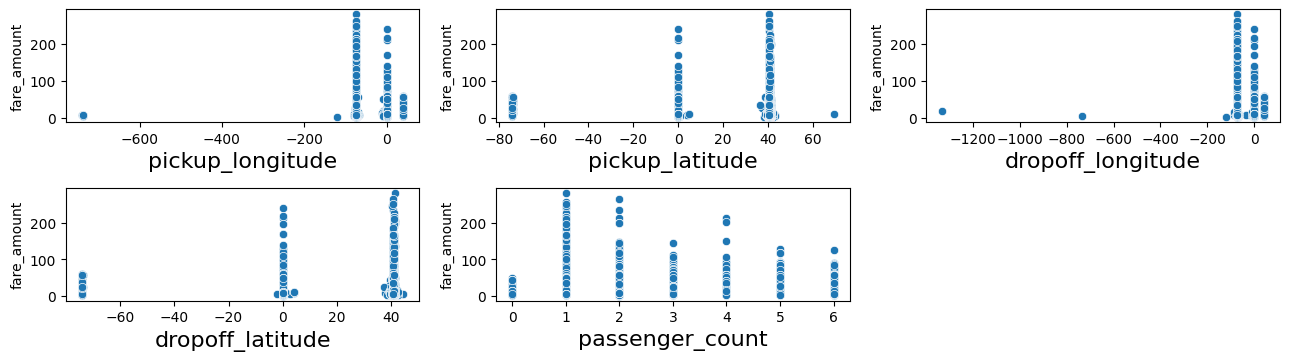

In [11]:
lat_lon=['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude', 'passenger_count', 'fare_amount']
plot_grid(train_fare[lat_lon],fig_size=(13,5), grid_size=(3,3), plot_type='scatterplot', target='fare_amount')

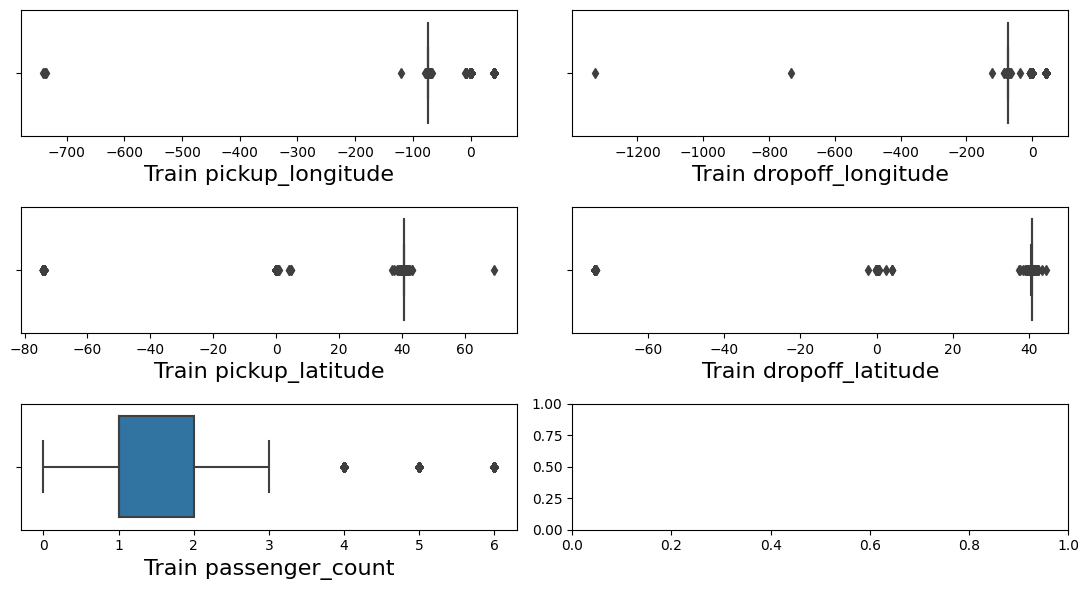

In [12]:
fig, axs = plt.subplots(3, 2, figsize=(11, 6))

p1 = sns.boxplot(x = train_fare['pickup_longitude'], ax=axs[0,0])
p1.set_xlabel('Train pickup_longitude', fontsize = 16)

plot = sns.boxplot(x = train_fare['pickup_latitude'], ax=axs[1,0])
plot.set_xlabel('Train pickup_latitude', fontsize = 16)

plot = sns.boxplot(x = train_fare['dropoff_longitude'], ax=axs[0,1])
plot.set_xlabel('Train dropoff_longitude', fontsize = 16)

plot = sns.boxplot(x = train_fare['dropoff_latitude'], ax=axs[1,1])
plot.set_xlabel('Train dropoff_latitude', fontsize = 16)

plot = sns.boxplot(x = train_fare['passenger_count'], ax=axs[2,0])
plot.set_xlabel('Train passenger_count', fontsize = 16)

plt.tight_layout()

In [13]:
# Drop outliers from raw data:
train_fare = train_fare.drop(train_fare[(train_fare['passenger_count'] < 1) | (train_fare['passenger_count'] > 6) | (train_fare['pickup_longitude'] <= -100)
                | (train_fare['dropoff_longitude'] <= -200) | (train_fare['dropoff_latitude'] <= -20) | (train_fare['pickup_latitude'] >= 50) | (train_fare['pickup_latitude'] <= -5)].index)
train_fare.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,abs_long_diff,abs_lat_diff,dist,manh_dist,...,is_weekend,season,dayofyear,is_leap_year,day_fraction,near_airport,is_rush_hour,high_fare_years,low_fare_years,holiday
count,398327.000000,398327.000000,398327.000000,398327.000000,398327.000000,398327.000000,398327.000000,398327.000000,398327.000000,398327.000000,...,398327.000000,398327.000000,398327.000000,398327.000000,398327.000000,398327.000000,398327.000000,398327.000000,398327.000000,398327.000000
mean,11.365341,-72.566063,39.978815,-72.561023,39.976706,1.689228,0.158463,0.090709,18.989907,24.833039,...,0.283277,2.454288,175.441775,0.159861,0.480446,0.471306,0.386968,0.623904,0.376096,0.020998
std,9.800953,10.111108,5.555994,10.125509,5.564821,1.305688,3.160792,1.681349,362.351860,482.003163,...,0.450590,1.103169,104.838541,0.366478,0.287092,0.499177,0.487057,0.484405,0.484405,0.143377
min,1.500000,-78.650908,-0.086092,-86.804122,-2.269701,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.002732,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,-73.992060,40.735008,-73.991370,40.734100,1.000000,0.005815,0.006592,1.215255,1.546930,...,0.000000,1.000000,85.000000,0.000000,0.232877,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.500000,-73.981796,40.752742,-73.980114,40.753213,1.000000,0.012505,0.013875,2.118563,2.720608,...,0.000000,2.000000,168.000000,0.000000,0.460274,0.000000,0.000000,1.000000,0.000000,0.000000
75%,12.500000,-73.967118,40.767114,-73.963585,40.768122,2.000000,0.023797,0.026945,3.889380,5.011586,...,1.000000,3.000000,267.000000,0.000000,0.731507,1.000000,1.000000,1.000000,1.000000,0.000000
max,281.050000,0.115070,43.183332,0.119188,44.416680,6.000000,75.423754,43.020333,8785.843243,12920.587057,...,1.000000,4.000000,366.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
# Drop unnecesary columns:
train_fare.drop(['pickup_datetime', 'key'], axis=1, inplace=True)
test_fare.drop(['pickup_datetime', 'key'], axis=1, inplace=True)
train_fare.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,abs_long_diff,abs_lat_diff,dist,manh_dist,...,is_weekend,season,dayofyear,is_leap_year,day_fraction,near_airport,is_rush_hour,high_fare_years,low_fare_years,holiday
0,4.5,-73.844311,40.721319,-73.841610,40.712278,1,0.002701,0.009041,1.030764,1.232937,...,0,3,166,0,0.454795,0,1,1,0,0
1,16.9,-74.016048,40.711303,-73.979268,40.782004,1,0.036780,0.070701,8.450134,10.961646,...,0,1,5,0,0.013699,0,1,1,0,0
2,5.7,-73.982738,40.761270,-73.991242,40.750562,2,0.008504,0.010708,1.389525,1.906909,...,0,3,230,0,0.630137,0,0,1,0,0
3,7.7,-73.987130,40.733143,-73.991567,40.758092,1,0.004437,0.024949,2.799270,3.148058,...,1,2,112,1,0.306011,0,0,1,0,0
4,5.3,-73.968095,40.768008,-73.956655,40.783762,1,0.011440,0.015754,1.999157,2.715180,...,0,2,68,0,0.186301,1,1,1,0,0


## Modeling:

In [15]:
X = train_fare.drop(['fare_amount'], axis=1)
y = train_fare['fare_amount']
X.head()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,abs_long_diff,abs_lat_diff,dist,manh_dist,distance_geod,...,is_weekend,season,dayofyear,is_leap_year,day_fraction,near_airport,is_rush_hour,high_fare_years,low_fare_years,holiday
0,-73.844311,40.721319,-73.841610,40.712278,1,0.002701,0.009041,1.030764,1.232937,1029.600744,...,0,3,166,0,0.454795,0,1,1,0,0
1,-74.016048,40.711303,-73.979268,40.782004,1,0.036780,0.070701,8.450134,10.961646,8443.441363,...,0,1,5,0,0.013699,0,1,1,0,0
2,-73.982738,40.761270,-73.991242,40.750562,2,0.008504,0.010708,1.389525,1.906909,1389.132160,...,0,3,230,0,0.630137,0,0,1,0,0
3,-73.987130,40.733143,-73.991567,40.758092,1,0.004437,0.024949,2.799270,3.148058,2795.789658,...,1,2,112,1,0.306011,0,0,1,0,0
4,-73.968095,40.768008,-73.956655,40.783762,1,0.011440,0.015754,1.999157,2.715180,1998.337836,...,0,2,68,0,0.186301,1,1,1,0,0


In [18]:
# Split the data 80/20:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Define the models and hyperparameter grids:
models = {
    'XGB': {
        'model': XGBRegressor(),
        'params': {
            'eta': [0.1, 0.2],
            'max_depth': [4, 6],
            'n_estimators': [50, 100],
        }
    },
    'CatBoost': {
        'model': CatBoostRegressor(verbose=False),
        'params': {
            'eta': [0.1, 0.2],
            'max_depth': [5, 8],
            'l2_leaf_reg': [5, 10],
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(),
        'params': {
            'n_estimators': [15, 30],
            'max_depth': [4, 6],
            'min_samples_split': [2, 4],
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(),
        'params': {
            'n_estimators': [15, 30],
            'learning_rate': [0.1, 0.2],
            'max_depth': [4, 6],
        }
    },
    'LGBM': {
        'model': LGBMRegressor(),
        'params': {
            'learning_rate': [0.1, 0.2],
            'max_depth': [4, 6],
            'n_estimators': [15, 30],
        }
    }
}

# Perform Grid Search CV for each model:
for name, config in models.items():
    print(f"Running GridSearchCV for {name}...")
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring='r2',  # Metric to optimize
        cv=3,  # 3-fold cross-validation
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    
    # Evaluate best model:
    best_model = grid_search.best_estimator_
    y_pred_test = best_model.predict(X_test)
    y_pred_train = best_model.predict(X_train)

    print(f"Best Params for {name}: {grid_search.best_params_}")
    print(f"R2 (Train): {r2_score(y_train, y_pred_train):.4f}")
    print(f"R2 (Test): {r2_score(y_test, y_pred_test):.4f}")
    print(f"RMSE (Train): {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
    print(f"RMSE (Test): {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
    print("\n")

Running GridSearchCV for XGB...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params for XGB: {'eta': 0.2, 'max_depth': 6, 'n_estimators': 100}
R2 (Train): 0.8692
R2 (Test): 0.8215
RMSE (Train): 3.5465
RMSE (Test): 4.1296


Running GridSearchCV for CatBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params for CatBoost: {'eta': 0.1, 'l2_leaf_reg': 10, 'max_depth': 8}
R2 (Train): 0.8846
R2 (Test): 0.8209
RMSE (Train): 3.3322
RMSE (Test): 4.1361


Running GridSearchCV for RandomForest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params for RandomForest: {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 30}
R2 (Train): 0.7829
R2 (Test): 0.7793
RMSE (Train): 4.5702
RMSE (Test): 4.5922


Running GridSearchCV for GradientBoosting...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params for GradientBoosting: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 30}
R2 (Train): 0.8481
R2 (Test): 0.8148

## Conclusions:

In [21]:
rmse_model = XGBRegressor(eta=0.2, max_depth=6, n_estimators=100)
rmse_model.fit(X_train, y_train)
importances = rmse_model.feature_importances_
feature_ranking = pd.DataFrame({'Feature': X.columns, 'Ranking': importances})
print(feature_ranking.sort_values(by='Ranking'))

                       Feature   Ranking
30             high_fare_years  0.000000
23                  is_weekend  0.000000
31              low_fare_years  0.000000
32                     holiday  0.001028
29                is_rush_hour  0.001240
4              passenger_count  0.001517
13                      second  0.001635
14                      minute  0.001960
16                         day  0.002021
24                      season  0.002188
25                   dayofyear  0.002294
1              pickup_latitude  0.002393
22                     weekday  0.002438
27                day_fraction  0.002712
15                        hour  0.002784
28                near_airport  0.002787
19                        week  0.003170
17                       month  0.003328
10              direction_geod  0.003534
18                   gas_price  0.003825
3             dropoff_latitude  0.003965
0             pickup_longitude  0.004430
6                 abs_lat_diff  0.004799
26              

In [22]:
r2_model = RandomForestRegressor(min_samples_split=2, max_depth=6, n_estimators=30)
r2_model.fit(X_train, y_train)
importances = r2_model.feature_importances_
feature_ranking = pd.DataFrame({'Feature': X.columns, 'Ranking': importances})
print(feature_ranking.sort_values(by='Ranking'))

                       Feature   Ranking
32                     holiday  0.000000
4              passenger_count  0.000000
17                       month  0.000003
24                      season  0.000003
19                        week  0.000007
13                      second  0.000014
23                  is_weekend  0.000017
29                is_rush_hour  0.000019
18                   gas_price  0.000029
26                is_leap_year  0.000039
16                         day  0.000096
25                   dayofyear  0.000102
27                day_fraction  0.000113
28                near_airport  0.000118
14                      minute  0.000177
22                     weekday  0.000200
15                        hour  0.000562
10              direction_geod  0.000644
21                    is_night  0.000896
11   pickup_distance_to_center  0.001506
31              low_fare_years  0.002954
1              pickup_latitude  0.002962
3             dropoff_latitude  0.003097
0             pi